# Reliable LIME under Query Budget Constraints


## 1. Reproduce LIME_IMAGE


The main libraries we will use:

- [numpy](https://numpy.org/doc/stable/reference/index.html): The basic tool for numerical computing in Python. It gives fast arrays and math operations.
- [scipy](https://docs.scipy.org/doc/scipy/reference/index.html#scipy-api): A collection of scientific algorithms built on top of NumPy, such as linear algebra.
- [scikit-learn](https://scikit-learn.org/stable/api/index.html): A classic machine learning library. It provides many models and evaluation utilities. In LIME, we need a simple interpretable surrogate model, usually a linear model like Ridge or Lasso, and scikit-learn provides these models and fitting tools.
- [scikit-image](https://scikit-image.org/docs/stable/api/api.html): An image processing library. It provides functions for segmentation, filtering, and feature extraction.
- [matplotlib](https://matplotlib.org/stable/users/index.html): Visualization of images


### 1.1 LIME_Image Workflow


- **Input**
  - An image instance $x$ to be expalined
  - A block-box classifier $f(x)$ that outputs class probabilities
  - Explanation settings, e.g., sampling budget $N$ (number of perturbed samples), and the number of superpixels to show $K$
- **Segment the image into superpixels**
  - There are groups of neighboring pixels that are similar in color or texture, and we merge these groups of neighboring pixels into a single region. This is so-called superpixel.
  - Partition the image into M superpixels.
  - In LIME_Image, each superpixel is trated as one interpretable feature.
- **Build mask of representation**
  - The mask is a binary vector $z\in{\{0,1\}}^M$.
  - For each postion, 0 means turning off that superpixel, 1 menas turning on that superpixel.
  - The original image corresponds to $z=\mathbf{1}$, meaning all superpixels are “on”
- **Generate perturbed samples**
  - Randomly sample many binary masks $z_i$, which keep different superpixels.
  - Based on $z_i$, we can construct a pertubed image $x_i$.
    - For the regions of superpixels kept, use the original pixels of image.
    - For the regions of superpixels switched-off, use a baseline, like gray, mean color or a blurred background.
- **Query the black-box model $f$**
  - For each perturbed image $x_i$, compute the model output $f(x_i)$
  - Then we get the taining pairs $(z_i, f(x_i))$
- **Compute proximity and assign weights**
  - Measure the distance between each perturbed image and original image.
  - Near perturbations get high weight (this is so-called "local"); Far perturbations get low weight.  
    Then we get $\pi_x(x_i)$, representing the weights of each $x_i$
  - This forces _local fidelity_: The fitted explainer $g$ is forced to match $f$ mainly around $x$
- **Fit a local interpretable surrogate model (expaliner) $g$**
  - For the expaliner $g$, it's typically a sparse model, like Lasso.
  - $\min\sum_{i=1}^N\pi_x(x_i)(f(x_i)-g(z_i))^2+penalty\ term$
  - The coefficients $w_j$ of fitted model/explainer $g(z)$ indicate the importance of superpixel $j$ for the prediction $f(x)$
- **Produce the explanation of visulazation**
  - Select the top-$K$ superpixels with the largest importance weights
  - Overlay the seleted regions on the original image to create the final explanation mask visualization.


### 1.2 lime_base


In [56]:
import numpy as np
import scipy as sp
from sklearn.utils import check_random_state

**Ridge Regression:**  
$\min_{\mathbf{w},\, b}\ \sum_{i=1}^{N}\ \big(y_i - \hat{y}_i\big)^2\ +\ \alpha \lVert \mathbf{w} \rVert_2^2$  
where:  
$\hat{y}_i=\mathbf{x}_i^\top \mathbf{w} + b$, which is the predictions of model  
$\lVert \mathbf{w} \rVert_2^2$ is the L2 regularization.


In [57]:
from sklearn.linear_model import Ridge, lars_path

Define a locally linear **sparse** model<br>
**Sparse** means the explanation model uses only a small subset of features, so most feature weights are zero or not included.


In [58]:
class LimeBase(object):
    def __init__(self,
                 kernel_fn,
                 verbose=False,
                 random_state=None):
        """
        Args:
            kernel_fn: converts distances into weights. 
                    Core of `local`: closer samples get higher weight, 
                                     far samples get lower weight.
            verbose: if true, print local prediction values from linear model.
            random_state: an integer or numpy.RandomState that will be used to
                generate random numbers. If None, the random state will be
                initialized using the internal numpy seed.
        """
        self.kernel_fn = kernel_fn
        self.verbose = verbose
        self.random_state = check_random_state(random_state)

    @staticmethod
    def generate_lars_path(weighted_data, weighted_labels):
        """Generates the lars path for weighted data.

        Args:
            weighted_data: data that has been weighted by kernel
            weighted_label: labels, weighted by kernel

        Returns:
            (alphas, coefs), both are arrays corresponding to the
            regularization parameter and coefficients, respectively
        """
        x_vector = weighted_data
        alphas, _, coefs = lars_path(x_vector,
                                     weighted_labels,
                                     method='lasso',
                                     verbose=False)
        return alphas, coefs
    
    # Greedy forward feature selection 
    def forward_selection(self, data, labels, weights, num_features):
        """Iteratively adds features to the model"""
        clf = Ridge(alpha=0, fit_intercept=True, random_state=self.random_state)
        used_features = []
        # Outer loop: select certain number of features
        for _ in range(min(num_features, data.shape[1])):
            # Search for the best next feature to add
            max_ = -100000000
            best = 0
            for feature in range(data.shape[1]):
                if feature in used_features:
                    continue
                # Fit a weighted linear model using the currently selected features plus the candidate feature.
                clf.fit(data[:, used_features + [feature]], labels,
                        sample_weight=weights)
                score = clf.score(data[:, used_features + [feature]],
                                  labels,
                                  sample_weight=weights)
                if score > max_:
                    best = feature
                    max_ = score
            used_features.append(best)
        # `used_features` is a list of feature indices.
        return np.array(used_features)

    def feature_selection(self, data, labels, weights, num_features, method):
        """Selects features for the model. see explain_instance_with_data to
           understand the parameters."""
        # `method == 'none'` use all features, no sparsity
        if method == 'none':
            return np.array(range(data.shape[1]))
        # Greedy selection we defined above
        elif method == 'forward_selection':
            return self.forward_selection(data, labels, weights, num_features)
        elif method == 'highest_weights':
            # Fit a weighted linear model on all features
            clf = Ridge(alpha=0.01, fit_intercept=True,
                        random_state=self.random_state)
            clf.fit(data, labels, sample_weight=weights)
            coef = clf.coef_
            # If `data`` is sparse -> avoid turning it into dense
            if sp.sparse.issparse(data):
                # Compressed Sparse Row matrix.
                coef = sp.sparse.csr_matrix(clf.coef_)
                weighted_data = coef.multiply(data[0])
                # Note: most efficient to slice the data before reversing
                sdata = len(weighted_data.data)
                # `argsort_data`` gives indices that would sort data by absolute value (small → large)
                argsort_data = np.abs(weighted_data.data).argsort()
                # Edge case where data is more sparse than requested number of feature importances
                # In that case, we just pad with zero-valued features
                if sdata < num_features:
                    nnz_indexes = argsort_data[::-1] # # all nonzeros, large → small
                    indices = weighted_data.indices[nnz_indexes] # feature indices for those nonzeros
                    num_to_pad = num_features - sdata
                    indices = np.concatenate((indices, np.zeros(num_to_pad, dtype=indices.dtype)))
                    indices_set = set(indices)
                    pad_counter = 0
                    for i in range(data.shape[1]):
                        if i not in indices_set:
                            indices[pad_counter + sdata] = i
                            pad_counter += 1
                            if pad_counter >= num_to_pad:
                                break
                else:
                    nnz_indexes = argsort_data[sdata - num_features:sdata][::-1]
                    indices = weighted_data.indices[nnz_indexes]
                return indices
            else:
                weighted_data = coef * data[0]
                feature_weights = sorted(
                    zip(range(data.shape[1]), weighted_data),
                    key=lambda x: np.abs(x[1]),
                    reverse=True)
                return np.array([x[0] for x in feature_weights[:num_features]])
        elif method == 'lasso_path':
            weighted_data = ((data - np.average(data, axis=0, weights=weights))
                             * np.sqrt(weights[:, np.newaxis]))
            weighted_labels = ((labels - np.average(labels, weights=weights))
                               * np.sqrt(weights))
            nonzero = range(weighted_data.shape[1])
            _, coefs = self.generate_lars_path(weighted_data,
                                               weighted_labels)
            for i in range(len(coefs.T) - 1, 0, -1):
                nonzero = coefs.T[i].nonzero()[0]
                if len(nonzero) <= num_features:
                    break
            used_features = nonzero
            return used_features
        elif method == 'auto':
            if num_features <= 6:
                n_method = 'forward_selection'
            else:
                n_method = 'highest_weights'
            return self.feature_selection(data, labels, weights,
                                          num_features, n_method)

    def explain_instance_with_data(self,
                                   neighborhood_data,
                                   neighborhood_labels,
                                   distances,
                                   label,
                                   num_features,
                                   feature_selection='auto',
                                   model_regressor=None):
        """Takes perturbed data, labels and distances, returns explanation.

        Args:
            neighborhood_data: perturbed data, 2d array. first element is
                               assumed to be the original data point.
            neighborhood_labels: corresponding perturbed labels. should have as
                                 many columns as the number of possible labels.
            distances: distances to original data point.
            label: label for which we want an explanation
            num_features: maximum number of features in explanation
            feature_selection: how to select num_features. options are:
                'forward_selection': iteratively add features to the model.
                    This is costly when num_features is high
                'highest_weights': selects the features that have the highest
                    product of absolute weight * original data point when
                    learning with all the features
                'lasso_path': chooses features based on the lasso
                    regularization path
                'none': uses all features, ignores num_features
                'auto': uses forward_selection if num_features <= 6, and
                    'highest_weights' otherwise.
            model_regressor: sklearn regressor to use in explanation.
                Defaults to Ridge regression if None. Must have
                model_regressor.coef_ and 'sample_weight' as a parameter
                to model_regressor.fit()

        Returns:
            (intercept, exp, score, local_pred):
            intercept is a float.
            exp is a sorted list of tuples, where each tuple (x,y) corresponds
            to the feature id (x) and the local weight (y). The list is sorted
            by decreasing absolute value of y.
            score is the R^2 value of the returned explanation
            local_pred is the prediction of the explanation model on the original instance
        """

        weights = self.kernel_fn(distances)
        labels_column = neighborhood_labels[:, label]
        used_features = self.feature_selection(neighborhood_data,
                                               labels_column,
                                               weights,
                                               num_features,
                                               feature_selection)
        if model_regressor is None:
            model_regressor = Ridge(alpha=1, fit_intercept=True,
                                    random_state=self.random_state)
        easy_model = model_regressor
        easy_model.fit(neighborhood_data[:, used_features],
                       labels_column, sample_weight=weights)
        prediction_score = easy_model.score(
            neighborhood_data[:, used_features],
            labels_column, sample_weight=weights)

        local_pred = easy_model.predict(neighborhood_data[0, used_features].reshape(1, -1))
        
        y_pred = easy_model.predict(neighborhood_data[:, used_features])
        easy_model._debug_y_true = labels_column
        easy_model._debug_y_pred = y_pred
        easy_model._debug_weights = weights
        easy_model._debug_used_features = used_features
        self._last_easy_model = easy_model
        
        if self.verbose:
            print('Intercept', easy_model.intercept_)
            print('Prediction_local', local_pred,)
            print('Right:', neighborhood_labels[0, label])
        return (easy_model.intercept_,
                sorted(zip(used_features, easy_model.coef_),
                       key=lambda x: np.abs(x[1]), reverse=True),
                prediction_score, local_pred)

### 1.3 lime_image


In [59]:
import copy
from functools import partial

import numpy as np
import sklearn
from sklearn.utils import check_random_state
from skimage.color import gray2rgb
from skimage.segmentation import felzenszwalb, slic, quickshift
from tqdm.auto import tqdm

import sys
import inspect
import types

In [60]:
def has_arg(fn, arg_name):
    """Checks if a callable accepts a given keyword argument.

    Args:
        fn: callable to inspect
        arg_name: string, keyword argument name to check

    Returns:
        bool, whether `fn` accepts a `arg_name` keyword argument.
    """
    if sys.version_info < (3,):
        if isinstance(fn, types.FunctionType) or isinstance(fn, types.MethodType):
            arg_spec = inspect.getargspec(fn)
        else:
            try:
                arg_spec = inspect.getargspec(fn.__call__)
            except AttributeError:
                return False
        return (arg_name in arg_spec.args)
    elif sys.version_info < (3, 6):
        arg_spec = inspect.getfullargspec(fn)
        return (arg_name in arg_spec.args or
                arg_name in arg_spec.kwonlyargs)
    else:
        try:
            signature = inspect.signature(fn)
        except ValueError:
            # handling Cython
            signature = inspect.signature(fn.__call__)
        parameter = signature.parameters.get(arg_name)
        if parameter is None:
            return False
        return (parameter.kind in (inspect.Parameter.POSITIONAL_OR_KEYWORD,
                                   inspect.Parameter.KEYWORD_ONLY))

In [61]:
class BaseWrapper(object):
    """Base class for LIME Scikit-Image wrapper


    Args:
        target_fn: callable function or class instance
        target_params: dict, parameters to pass to the target_fn


    'target_params' takes parameters required to instanciate the
        desired Scikit-Image class/model
    """

    def __init__(self, target_fn=None, **target_params):
        self.target_fn = target_fn
        self.target_params = target_params

    def _check_params(self, parameters):
        """Checks for mistakes in 'parameters'

        Args :
            parameters: dict, parameters to be checked

        Raises :
            ValueError: if any parameter is not a valid argument for the target function
                or the target function is not defined
            TypeError: if argument parameters is not iterable
         """
        a_valid_fn = []
        if self.target_fn is None:
            if callable(self):
                a_valid_fn.append(self.__call__)
            else:
                raise TypeError('invalid argument: tested object is not callable,\
                 please provide a valid target_fn')
        elif isinstance(self.target_fn, types.FunctionType) \
                or isinstance(self.target_fn, types.MethodType):
            a_valid_fn.append(self.target_fn)
        else:
            a_valid_fn.append(self.target_fn.__call__)

        if not isinstance(parameters, str):
            for p in parameters:
                for fn in a_valid_fn:
                    if has_arg(fn, p):
                        pass
                    else:
                        raise ValueError('{} is not a valid parameter'.format(p))
        else:
            raise TypeError('invalid argument: list or dictionnary expected')

    def set_params(self, **params):
        """Sets the parameters of this estimator.
        Args:
            **params: Dictionary of parameter names mapped to their values.

        Raises :
            ValueError: if any parameter is not a valid argument
                for the target function
        """
        self._check_params(params)
        self.target_params = params

    def filter_params(self, fn, override=None):
        """Filters `target_params` and return those in `fn`'s arguments.
        Args:
            fn : arbitrary function
            override: dict, values to override target_params
        Returns:
            result : dict, dictionary containing variables
            in both target_params and fn's arguments.
        """
        override = override or {}
        result = {}
        for name, value in self.target_params.items():
            if has_arg(fn, name):
                result.update({name: value})
        result.update(override)
        return result


class SegmentationAlgorithm(BaseWrapper):
    """ Define the image segmentation function based on Scikit-Image
            implementation and a set of provided parameters

        Args:
            algo_type: string, segmentation algorithm among the following:
                'quickshift', 'slic', 'felzenszwalb'
            target_params: dict, algorithm parameters (valid model paramters
                as define in Scikit-Image documentation)
    """

    def __init__(self, algo_type, **target_params):
        self.algo_type = algo_type
        if (self.algo_type == 'quickshift'):
            BaseWrapper.__init__(self, quickshift, **target_params)
            kwargs = self.filter_params(quickshift)
            self.set_params(**kwargs)
        elif (self.algo_type == 'felzenszwalb'):
            BaseWrapper.__init__(self, felzenszwalb, **target_params)
            kwargs = self.filter_params(felzenszwalb)
            self.set_params(**kwargs)
        elif (self.algo_type == 'slic'):
            BaseWrapper.__init__(self, slic, **target_params)
            kwargs = self.filter_params(slic)
            self.set_params(**kwargs)

    def __call__(self, *args):
        return self.target_fn(args[0], **self.target_params)

In [62]:
class ImageExplanation(object):
    def __init__(self, image, segments):
        """Init function.

        Args:
            image: 3d numpy array
            segments: 2d numpy array, with the output from skimage.segmentation
        """
        self.image = image
        self.segments = segments
        self.intercept = {}
        self.local_exp = {}
        self.local_pred = {}
        self.score = {}

    def get_image_and_mask(self, label, positive_only=True, negative_only=False, hide_rest=False,
                           num_features=5, min_weight=0.):
        """Init function.

        Args:
            label: label to explain
            positive_only: if True, only take superpixels that positively contribute to
                the prediction of the label.
            negative_only: if True, only take superpixels that negatively contribute to
                the prediction of the label. If false, and so is positive_only, then both
                negativey and positively contributions will be taken.
                Both can't be True at the same time
            hide_rest: if True, make the non-explanation part of the return
                image gray
            num_features: number of superpixels to include in explanation
            min_weight: minimum weight of the superpixels to include in explanation

        Returns:
            (image, mask), where image is a 3d numpy array and mask is a 2d
            numpy array that can be used with
            skimage.segmentation.mark_boundaries
        """
        if label not in self.local_exp:
            raise KeyError('Label not in explanation')
        if positive_only & negative_only:
            raise ValueError("Positive_only and negative_only cannot be true at the same time.")
        segments = self.segments
        image = self.image
        exp = self.local_exp[label]
        mask = np.zeros(segments.shape, segments.dtype)
        if hide_rest:
            temp = np.zeros(self.image.shape)
        else:
            temp = self.image.copy()
        if positive_only:
            fs = [x[0] for x in exp
                  if x[1] > 0 and x[1] > min_weight][:num_features]
        if negative_only:
            fs = [x[0] for x in exp
                  if x[1] < 0 and abs(x[1]) > min_weight][:num_features]
        if positive_only or negative_only:
            for f in fs:
                temp[segments == f] = image[segments == f].copy()
                mask[segments == f] = 1
            return temp, mask
        else:
            for f, w in exp[:num_features]:
                if np.abs(w) < min_weight:
                    continue
                c = 0 if w < 0 else 1
                mask[segments == f] = -1 if w < 0 else 1
                temp[segments == f] = image[segments == f].copy()
                temp[segments == f, c] = np.max(image)
            return temp, mask


class LimeImageExplainer(object):
    """Explains predictions on Image (i.e. matrix) data.
    For numerical features, perturb them by sampling from a Normal(0,1) and
    doing the inverse operation of mean-centering and scaling, according to the
    means and stds in the training data. For categorical features, perturb by
    sampling according to the training distribution, and making a binary
    feature that is 1 when the value is the same as the instance being
    explained."""

    def __init__(self, kernel_width=.25, kernel=None, verbose=False,
                 feature_selection='auto', random_state=None):
        """Init function.

        Args:
            kernel_width: kernel width for the exponential kernel.
            If None, defaults to sqrt(number of columns) * 0.75.
            kernel: similarity kernel that takes euclidean distances and kernel
                width as input and outputs weights in (0,1). If None, defaults to
                an exponential kernel.
            verbose: if true, print local prediction values from linear model
            feature_selection: feature selection method. can be
                'forward_selection', 'lasso_path', 'none' or 'auto'.
                See function 'explain_instance_with_data' in lime_base.py for
                details on what each of the options does.
            random_state: an integer or numpy.RandomState that will be used to
                generate random numbers. If None, the random state will be
                initialized using the internal numpy seed.
        """
        kernel_width = float(kernel_width)

        if kernel is None:
            def kernel(d, kernel_width):
                return np.sqrt(np.exp(-(d ** 2) / kernel_width ** 2))

        kernel_fn = partial(kernel, kernel_width=kernel_width)

        self.random_state = check_random_state(random_state)
        self.feature_selection = feature_selection
        self.base = LimeBase(kernel_fn, verbose, random_state=self.random_state)

    def explain_instance(self, image, classifier_fn, labels=(1,),
                         hide_color=None,
                         top_labels=5, num_features=100000, num_samples=1000,
                         batch_size=10,
                         segmentation_fn=None,
                         distance_metric='cosine',
                         model_regressor=None,
                         random_seed=None,
                         progress_bar=True):
        """Generates explanations for a prediction.

        First, we generate neighborhood data by randomly perturbing features
        from the instance (see __data_inverse). We then learn locally weighted
        linear models on this neighborhood data to explain each of the classes
        in an interpretable way (see lime_base.py).

        Args:
            image: 3 dimension RGB image. If this is only two dimensional,
                we will assume it's a grayscale image and call gray2rgb.
            classifier_fn: classifier prediction probability function, which
                takes a numpy array and outputs prediction probabilities.  For
                ScikitClassifiers , this is classifier.predict_proba.
            labels: iterable with labels to be explained.
            hide_color: If not None, will hide superpixels with this color.
                Otherwise, use the mean pixel color of the image.
            top_labels: if not None, ignore labels and produce explanations for
                the K labels with highest prediction probabilities, where K is
                this parameter.
            num_features: maximum number of features present in explanation
            num_samples: size of the neighborhood to learn the linear model
            batch_size: batch size for model predictions
            distance_metric: the distance metric to use for weights.
            model_regressor: sklearn regressor to use in explanation. Defaults
            to Ridge regression in LimeBase. Must have model_regressor.coef_
            and 'sample_weight' as a parameter to model_regressor.fit()
            segmentation_fn: SegmentationAlgorithm, wrapped skimage
            segmentation function
            random_seed: integer used as random seed for the segmentation
                algorithm. If None, a random integer, between 0 and 1000,
                will be generated using the internal random number generator.
            progress_bar: if True, show tqdm progress bar.

        Returns:
            An ImageExplanation object (see lime_image.py) with the corresponding
            explanations.
        """
        if len(image.shape) == 2:
            image = gray2rgb(image)
        if random_seed is None:
            random_seed = self.random_state.randint(0, high=1000)

        if segmentation_fn is None:
            segmentation_fn = SegmentationAlgorithm('quickshift', kernel_size=4,
                                                    max_dist=200, ratio=0.2,
                                                    random_seed=random_seed)
        segments = segmentation_fn(image)

        fudged_image = image.copy()
        if hide_color is None:
            for x in np.unique(segments):
                fudged_image[segments == x] = (
                    np.mean(image[segments == x][:, 0]),
                    np.mean(image[segments == x][:, 1]),
                    np.mean(image[segments == x][:, 2]))
        else:
            fudged_image[:] = hide_color

        top = labels

        data, labels = self.data_labels(image, fudged_image, segments,
                                        classifier_fn, num_samples,
                                        batch_size=batch_size,
                                        progress_bar=progress_bar)

        distances = sklearn.metrics.pairwise_distances(
            data,
            data[0].reshape(1, -1),
            metric=distance_metric
        ).ravel()

        ret_exp = ImageExplanation(image, segments)
        
        if top_labels:
            top = np.argsort(labels[0])[-top_labels:]
            ret_exp.top_labels = list(top)
            ret_exp.top_labels.reverse()
        for label in top:
            (ret_exp.intercept[label],
             ret_exp.local_exp[label],
             ret_exp.score[label],
             ret_exp.local_pred[label]) = self.base.explain_instance_with_data(
                data, labels, distances, label, num_features,
                model_regressor=model_regressor,
                feature_selection=self.feature_selection)
            if not hasattr(ret_exp, "_debug_easy_models"):
                ret_exp._debug_easy_models = {}
                ret_exp._debug_easy_models[label] = getattr(self.base, "_last_easy_model", None)
        return ret_exp

    def data_labels(self,
                    image,
                    fudged_image,
                    segments,
                    classifier_fn,
                    num_samples,
                    batch_size=10,
                    progress_bar=True):
        """Generates images and predictions in the neighborhood of this image.

        Args:
            image: 3d numpy array, the image
            fudged_image: 3d numpy array, image to replace original image when
                superpixel is turned off
            segments: segmentation of the image
            classifier_fn: function that takes a list of images and returns a
                matrix of prediction probabilities
            num_samples: size of the neighborhood to learn the linear model
            batch_size: classifier_fn will be called on batches of this size.
            progress_bar: if True, show tqdm progress bar.

        Returns:
            A tuple (data, labels), where:
                data: dense num_samples * num_superpixels
                labels: prediction probabilities matrix
        """
        n_features = np.unique(segments).shape[0]
        data = self.random_state.randint(0, 2, num_samples * n_features)\
            .reshape((num_samples, n_features))
        labels = []
        data[0, :] = 1
        imgs = []
        rows = tqdm(data, leave=False) if progress_bar else data
        for row in rows:
            temp = copy.deepcopy(image)
            zeros = np.where(row == 0)[0]
            mask = np.zeros(segments.shape).astype(bool)
            for z in zeros:
                mask[segments == z] = True
            temp[mask] = fudged_image[mask]
            imgs.append(temp)
            if len(imgs) == batch_size:
                preds = classifier_fn(np.array(imgs))
                labels.extend(preds)
                imgs = []
        if len(imgs) > 0:
            preds = classifier_fn(np.array(imgs))
            labels.extend(preds)
        return data, np.array(labels)

### 1.4 Sanity Check


In [63]:
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from skimage import data
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

We select **[ResNet18](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html#torchvision.models.resnet18)** as the example of black-box  
It is a convolutional neural network (CNN) used for image classification


In [64]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights).to(device).eval()
preprocess = weights.transforms()

In [65]:
@torch.no_grad()
def classifier_fn(images_np):
    # images_np: (N, H, W, 3), float in [0, 1]
    imgs = []
    for img in images_np:
        img = img.astype(np.float32)
        t = preprocess(torch.from_numpy(img).permute(2,0,1))  # HWC -> CHW
        imgs.append(t)
    batch = torch.stack(imgs, dim=0).to(device)
    probs = F.softmax(model(batch), dim=1).detach().cpu().numpy()
    return probs

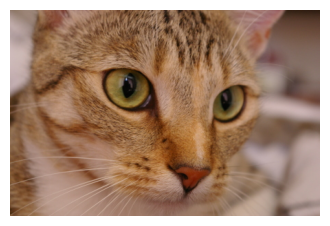

In [66]:
img = data.cat()  # H,W,3 uint8
img = img.astype(np.float32) / 255.0

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.show()

In [67]:
BUDGET = 200
explainer = LimeImageExplainer(random_state=0)
explanation = explainer.explain_instance(
    img,
    classifier_fn,
    top_labels=5,
    hide_color=0,
    num_samples=BUDGET  # This is the budget, we'll play with it!
)

print("top labels:", explanation.top_labels)

top labels: [285, 282, 281, 287, 283]


285 Egyptian cat
surrogate score: {283: 0.5348068924499609, 287: 0.6576877614006502, 281: 0.6458582705269662, 282: 0.6436053826971226, 285: 0.6463135800549638}
top superpixels: [(69, 0.013567470554531173), (35, 0.012978895147124518), (95, 0.012936641540737861), (31, 0.012612483369709212), (40, 0.012502875203242777), (46, 0.010780552151935324), (18, 0.010767922839707796), (68, 0.010610999469885713), (51, 0.010390992385198895), (70, 0.010171265740593096)]


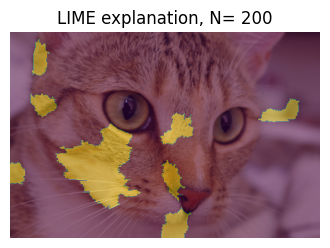

In [68]:
label = explanation.top_labels[0]
categories = weights.meta["categories"]
print(label, categories[label])
print("surrogate score:", explanation.score)
print("top superpixels:", explanation.local_exp[label][:10])
temp, mask = explanation.get_image_and_mask(
    label,
    positive_only=True,
    num_features=10,   # K = 10
    hide_rest=False
)

plt.figure(figsize=(4,4))
plt.imshow(temp)
plt.imshow(mask, alpha=0.4)
plt.axis("off")
plt.title(f"LIME explanation, N= {BUDGET}")
plt.show()

## 2. Budget sweep experiment


Definition: Budget $N$ is the number of perturbed samples, i.e., the number of $(z_i, f(x_i))$ pairs used to fit the local explainer $g$  
$N$ = number of perturbations = number of black-box queries = number of pairs used to fit $g$


### 2.1 Budegt sweep visualization


In [69]:
from skimage.segmentation import slic

def make_fixed_segmentation_fn(img, n_segments=100, compactness=10, sigma=1):
    segments = slic(img, n_segments=n_segments, compactness=compactness, sigma=sigma, start_label=0)
    return segments, (lambda x: segments)

In [70]:
def run_lime_image_once(
    img,
    classifier_fn,
    segmentation_fn,
    budget,
    seed=0,
    top_labels=5,
    hide_color=0,
    num_features=10,
    positive_only=True,
):
    explainer = LimeImageExplainer(random_state=seed)
    exp = explainer.explain_instance(
        img,
        classifier_fn,
        top_labels=top_labels,
        hide_color=hide_color,
        num_samples=budget,
        segmentation_fn=segmentation_fn
    )
    label = exp.top_labels[0]
    temp, mask = exp.get_image_and_mask(
        label,
        positive_only=positive_only,
        num_features=num_features,
        hide_rest=False
    )
    return {
        "budget": budget,
        "seed": seed,
        "label": label,
        "temp": temp,
        "mask": mask,
        "exp": exp,
        "score": exp.score if hasattr(exp, "score") else None,
    }

In [71]:
import math
def plot_budget_sweep(
    img,
    classifier_fn,
    budgets,
    segmentation_fn,
    seed=0,
    num_features=10,
    positive_only=True,
    title_prefix="LIME",
):
    categories = None
    try:
        categories = models.ResNet18_Weights.DEFAULT.meta["categories"]
    except Exception:
        pass
    results = []
    n = len(budgets)
    ncols = 3
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(4*ncols, 4*nrows))
    for i, B in enumerate(budgets, 1):
        print(f"[{i}/{len(budgets)}] budget={B}, seed={seed} ...", end="")
        r = run_lime_image_once(
            img, classifier_fn, segmentation_fn,
            budget=B, seed=seed, num_features=num_features,
            positive_only=positive_only
        )
        results.append(r)
        label = r["label"]
        name = categories[label] if categories is not None else str(label)

        plt.subplot(nrows, ncols, i)
        plt.imshow(r["temp"])
        plt.imshow(r["mask"], alpha=0.4)
        plt.axis("off")
        plt.title(f"{title_prefix}, N={B}\n{label} {name}")
    plt.tight_layout()
    plt.show()
    return results

[1/9] budget=200, seed=0 ...

[2/9] budget=500, seed=0 ...

[3/9] budget=1000, seed=0 ...

[4/9] budget=2000, seed=0 ...

KeyboardInterrupt: 

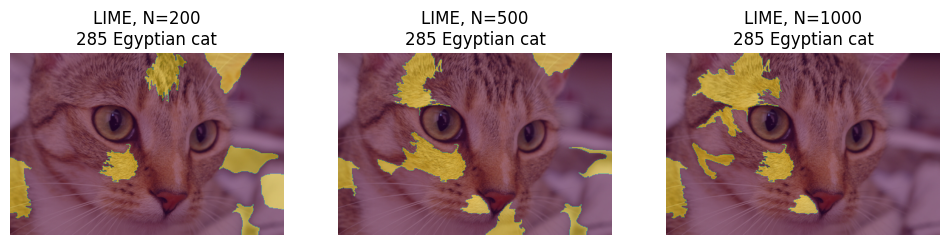

In [72]:
segments, segmentation_fn = make_fixed_segmentation_fn(img, n_segments=100, compactness=10)
budgets = [200, 500, 1000, 2000, 3000, 5000, 8000, 12000, 20000]
results = plot_budget_sweep(img, classifier_fn, budgets, segmentation_fn, seed=0)

Check the results in `./results/budget_200to100000.png`  
As budget $N$ increases, the explanation stabilizes and “locks onto” the eye/face region, and after a certain point we mainly see small fluctuations rather than a qualitatively new explanation, which means we can early stop.

- 200–1000: noisy, scattered superpixels, lots of variation.
- 2000–5000: the main region becomes consistent (eye/cheek area).
- 8000–100000: mostly the same core region, only minor additions or shifts.

Thus, stopping at 5000 or 20000 is defensible.


Simply visulazation is human-intuitive. However, quantative metrics are more numerically measurable.


### 2.2 Numerical metrics


We define four metrics to measure the performance of expaliner

- **Stability (repeated-run consistency)**  
   Run LIME multiple times with different seeds at the same budget, then compare explanations  
   _e.g._ Jaccard overlap of top-k superpixels.
- **Faithfulness deletion test**  
   Take the top-k superpixels, mask them out in the original image, and measure the drop in the black-box probability (or compute an AUC over k).
- **Fidelity**  
   Surrogate fit score is available in original code.
- **Cost**
  - Budget $N$ = Queries = `num_samples`
  - Runtime per explanation


In [73]:
def get_ref_label(img, classifier_fn):
    p = classifier_fn(img[None, ...])[0]
    return int(np.argmax(p)), p

ref_label, p0_all = get_ref_label(img, classifier_fn)
print("ref_label =", ref_label, "p0 =", float(p0_all[ref_label]))

ref_label = 285 p0 = 0.39580029249191284


In [74]:
import time

def run_lime_image_once_fixed_label(
    img,
    classifier_fn,
    segmentation_fn,
    budget,
    label_to_explain=None,
    seed=0,
    top_labels=5,
    hide_color=0,
    num_features=10,
    positive_only=True,
):
    explainer = LimeImageExplainer(random_state=seed)

    t0 = time.perf_counter()
    if label_to_explain is not None:
        try:
            exp = explainer.explain_instance(
                img,
                classifier_fn,
                labels=[label_to_explain],
                top_labels=None,
                hide_color=hide_color,
                num_samples=budget,
                segmentation_fn=segmentation_fn
            )
            label = label_to_explain
        except TypeError:
            exp = explainer.explain_instance(
                img,
                classifier_fn,
                top_labels=top_labels,
                hide_color=hide_color,
                num_samples=budget,
                segmentation_fn=segmentation_fn
            )
            label = label_to_explain if label_to_explain in exp.local_exp else exp.top_labels[0]
    else:
        exp = explainer.explain_instance(
            img,
            classifier_fn,
            top_labels=top_labels,
            hide_color=hide_color,
            num_samples=budget,
            segmentation_fn=segmentation_fn
        )
        label = exp.top_labels[0]
    t1 = time.perf_counter()

    temp, mask = exp.get_image_and_mask(
        label,
        positive_only=positive_only,
        num_features=num_features,
        hide_rest=False
    )

    return {
        "budget": budget,
        "seed": seed,
        "label": label,
        "temp": temp,
        "mask": mask,
        "exp": exp,
        "score": exp.score if hasattr(exp, "score") else None,
        # Cost
        "runtime_sec": t1 - t0,
        "queries": budget,
    }

#### **Fidelity** (Directly use `explanation.score`)

Weighted Mean Squared Error(WMSE)

$\mathrm{WMSE}=\frac{\sum_{i=1}^{N} w_i\,(y_i-\hat{y}_i)^2}{\sum_{i=1}^{N} w_i}$

Where

- $N$ is the number of perturbed samples, $N = \texttt{num\_samples}$
- $w_i$ is the kernel weight for sample $i$
- $y_i$ is the black-box output for the explained class on perturbed sample $i$
- $\hat{y}_i$ is the surrogate model prediction for that sample


In [75]:
def fidelity_wmse_from_run(r, label=None):
    exp = r["exp"]
    if label is None:
        label = r["label"]
    m = exp._debug_easy_models[label]
    y_true = m._debug_y_true
    y_pred = m._debug_y_pred
    w = m._debug_weights
    return float(np.sum(w * (y_true - y_pred)**2) / np.sum(w))


In [76]:
segments, segmentation_fn = make_fixed_segmentation_fn(img, n_segments=100, compactness=10)
r = run_lime_image_once_fixed_label(img, classifier_fn, segmentation_fn, budget=200, label_to_explain=ref_label, seed=0)
print(r["exp"]._debug_easy_models.keys())
print("wmse:", fidelity_wmse_from_run(r, ref_label))

dict_keys([285])
wmse: 0.0006280371092356995


#### **Stability** (Same budget with different seeds, gettin the Jaccard of top-K superpixels)


In [77]:
import itertools

def topk_superpixels_from_exp(exp, label, k=10):
    local_exp = exp.local_exp[label]  # list of (sp_id, weight)
    local_exp = sorted(local_exp, key=lambda t: abs(t[1]), reverse=True)
    return [int(sp_id) for sp_id, _ in local_exp[:k]]

def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / max(1, len(a | b))

def stability_jaccard(run_list, k=10):
    topks = [topk_superpixels_from_exp(r["exp"], r["label"], k=k) for r in run_list]
    if len(topks) < 2:
        return np.nan
    vals = [jaccard(a, b) for a, b in itertools.combinations(topks, 2)]
    return float(np.mean(vals))

#### **Faithfulness** (deletion test, deleting top-K superpixels and checking the drop of probability)


In [78]:
def mask_superpixels(img, segments, sp_ids, hide_color=0):
    out = img.copy()
    if np.isscalar(hide_color):
        fill = np.array([hide_color, hide_color, hide_color], dtype=out.dtype)
    else:
        fill = np.array(hide_color, dtype=out.dtype).reshape(3,)
    m = np.isin(segments, np.array(sp_ids, dtype=int))
    out[m] = fill
    return out

def deletion_test(img, segments, classifier_fn, label, topk_ids, hide_color=0, k=10):
    p0 = float(classifier_fn(img[None, ...])[0, label])
    probs = [p0]
    for m in range(1, k + 1):
        img_del = mask_superpixels(img, segments, topk_ids[:m], hide_color=hide_color)
        pm = float(classifier_fn(img_del[None, ...])[0, label])
        probs.append(pm)

    probs = np.array(probs, dtype=float)
    drops = probs[0] - probs

    x = np.linspace(0, 1, k + 1)
    drop_k = float(drops[-1])

    return drop_k

Run budget sweep with different seeds, ouputing mertrics of budgets.


In [79]:
import pandas as pd
from IPython.display import clear_output

def budget_sweep_metrics(
    run_once_fn,
    img, segments, segmentation_fn, classifier_fn,
    budgets, seeds, ref_label,
    k=10, hide_color=0, num_features=10, positive_only=True,
    run_once_kwargs=None
):  
    if run_once_kwargs is None:
        run_once_kwargs = {}
    rows = []
    summary_rows = []

    total = len(budgets) * len(seeds)
    run_idx = 0

    for budget_idx,B in enumerate(budgets):
        runs_B = []
        for seed_idx, s in enumerate(seeds):
            run_idx += 1
            clear_output(wait=True)
            print(f"\033[1m[{budget_idx+1}/{len(budgets)}] Budget={B}\033[0m")
            print(f"[{seed_idx+1}/{len(seeds)}] budget={B}, seed={s}")
            r = run_once_fn(
                img, classifier_fn, segmentation_fn,
                budget=B, label_to_explain=ref_label,
                seed=s, hide_color=hide_color,
                num_features=num_features, positive_only=positive_only,
                **run_once_kwargs
            )
            runs_B.append(r)

            fid_wmse = fidelity_wmse_from_run(r, ref_label)
            topk = topk_superpixels_from_exp(r["exp"], r["label"], k=k)
            drop_k = deletion_test(
                img, segments, classifier_fn,
                label=r["label"], topk_ids=topk,
                hide_color=hide_color, k=k
            )

            rows.append({
                "budget": B,
                "seed": s,
                "label": r["label"],
                "stability_jaccard": np.nan,
                "fidelity_wmse": fid_wmse,
                "faith_drop_k": drop_k,
                "runtime_sec": r["runtime_sec"],
                "queries": r["queries"],
            })
        stab = stability_jaccard(runs_B, k=k)
        for rr in rows[-len(seeds):]:
            rr["stability_jaccard"] = stab

        dfB = pd.DataFrame(rows[-len(seeds):])
        summary_rows.append({
            "budget": B,
            "stability_jaccard": stab,
            "fidelity_wmse_mean": float(dfB["fidelity_wmse"].mean()),
            "faith_drop_k_mean": float(dfB["faith_drop_k"].mean()),
            "runtime_sec_mean": float(dfB["runtime_sec"].mean()),
            "queries": B
        })

    df_runs = pd.DataFrame(rows)
    df_summary = pd.DataFrame(summary_rows).sort_values("budget")
    return df_runs, df_summary

### 2.3 Experiment Results


In [80]:
budgets = [200, 500, 1000, 2000, 3000, 5000]
seeds = list(range(10))
segments, segmentation_fn = make_fixed_segmentation_fn(img, n_segments=100, compactness=10)

df_runs, df_summary = budget_sweep_metrics(
    run_once_fn=run_lime_image_once_fixed_label,
    img=img, segments=segments, segmentation_fn=segmentation_fn, classifier_fn=classifier_fn,
    budgets=budgets, seeds=seeds, ref_label=ref_label,
    k=10, hide_color=0
)
df_summary

[1/6] Budget=200
[2/10] budget=200, seed=1


KeyboardInterrupt: 

For readability, we scale `fidelity_wmse_mean` by 1000

In [81]:
df_summary["fidelity_wmse_mean"] = df_summary["fidelity_wmse_mean"]*1000
df_summary

,budget,stability_jaccard,fidelity_wmse_mean,faith_drop_k_mean,runtime_sec_mean,queries
0,200,0.063357,0.770171,-0.056229,3.297551,200
1,500,0.078984,0.549426,-0.018505,7.323061,500


## 3. Lightweight improvement under limited budget


### 3.1 Possible directions

1. **Adaptive Budget (popular)**  
   Dynamically choose the number of perturbation samples $N$ for each instance, using more queries when the explanation is unsstable and stopping early when it becomes stable.  
2. **Budget Allocation Optimization**
   - 2.1 **Coarse-to-Fine Budget Allocation(We implement this)**  
      Spend a small budget to quickly find candidate important features first, then use the remaining budget to refine the explanation by focusing perturbations on those candidates.  
   - 2.2 **Repeated LIME with Split Budget and Aggregation**  
     Split the budget $N$ into $R$ samller runs (e.g., $R=5$, each with $\frac{N}{R}$ perturbations), run LIME R times with different seeds, and then aggregate the feature weights (e.g., mean or median) to produce the final explanation.
3. **Balanced Mask Sampling**  
   Design perturbation masks so each feature is turned on and off a similar number of times, reducing sampling variance and making LIME more stable under samll $N$.

We view the possible improvements in three layers:
- adaptive budget selection (how many queries),
- budget allocation (how to spend the queries),
- and variance-reduced sampling (how to generate perturbations).


### 3.2 Coarse-to-Fine Budget Allocation

In [94]:
import numpy as np
import time
import sklearn
from sklearn.linear_model import Ridge

def _hide_color_rgb(hide_color, image):
    # image: HWC float in [0,1]
    if hide_color is None:
        return np.mean(image.reshape(-1, 3), axis=0)
    if np.isscalar(hide_color):
        return np.array([hide_color, hide_color, hide_color], dtype=image.dtype)
    return np.array(hide_color, dtype=image.dtype).reshape(3,)

def _apply_mask(image, segments, z, hide_rgb):
    """
    image: (H,W,3) float
    segments: (H,W) int superpixel ids 0..K-1
    z: (K,) binary mask, 1 keep, 0 hide
    """
    out = image.copy()
    off_ids = np.where(z == 0)[0]
    for sp_id in off_ids:
        out[segments == sp_id] = hide_rgb
    return out

def _sample_masks_random(rng, n, K, p_on=0.5):
    Z = (rng.random((n, K)) < p_on).astype(np.int32)
    Z[0, :] = 1  # keep the original instance
    return Z

def _sample_masks_focus_candidates(rng, n, K, candidates, p_on_cand=0.5):
    """
    Non-candidates are kept ON. Only candidates are toggled.
    """
    Z = np.ones((n, K), dtype=np.int32)
    Z[0, :] = 1
    cand = np.array(sorted(list(candidates)), dtype=int)

    if len(cand) == 0:
        return _sample_masks_random(rng, n, K, p_on=0.5)

    Z[1:, cand] = (rng.random((n - 1, len(cand))) < p_on_cand).astype(np.int32)
    return Z

def _batched_classifier(classifier_fn, imgs, batch_size=32):
    outs = []
    for i in range(0, len(imgs), batch_size):
        outs.append(classifier_fn(imgs[i:i+batch_size]))
    return np.concatenate(outs, axis=0)

In [113]:
from tqdm.auto import tqdm
import numpy as np
import sklearn
from sklearn.linear_model import Ridge

def explain_instance_coarse_to_fine(
    image,
    classifier_fn,
    segmentation_fn,
    label_to_explain,
    budget,
    seed=0,
    hide_color=0,
    num_features=10,
    distance_metric="cosine",
    coarse_frac=0.2,     # will be overwritten if adaptive_coarse=True
    candidate_k=20,      # base candidate size, will be enlarged by candidate_k_eff
    batch_size=32,
    p_on_stage1=0.5,
    p_on_stage2=0.5,
    epsilon=0.2,         # fine stage exploration ratio, e.g., 0.2 means 20% random masks
    adaptive_coarse=True # adapt coarse_frac based on total budget
):
    """
    Two-stage sampling (Coarse-to-Fine) with variance reduction guards:
      - Stage 1: random masks with N1 -> get candidates (screening)
      - Stage 2: mixture sampling with N2:
          (1-epsilon) focus on candidates + epsilon global random (exploration)
      - Candidate set is enlarged to improve recall.

    Notes:
      - Total queries remain = budget.
      - This does not guarantee improvement for all cases, but reduces selection bias risk.
    """
    rng = np.random.default_rng(seed)

    # Use LimeImageExplainer only for accessing LimeBase (explainer.base) and kernel
    explainer = LimeImageExplainer(random_state=seed)

    # Fixed segmentation
    segments = segmentation_fn(image)
    K = int(segments.max() + 1)

    hide_rgb = _hide_color_rgb(hide_color, image)

    # adaptive coarse fraction (optional but recommended)
    if adaptive_coarse:
        if budget <= 500:
            coarse_frac = 0.5
        elif budget <= 2000:
            coarse_frac = 0.3
        else:
            coarse_frac = 0.2

    # split budget
    N1 = int(max(50, round(coarse_frac * budget)))
    N1 = min(N1, budget - 10) if budget > 60 else max(10, budget // 2)
    N2 = budget - N1
    if N2 < 10:
        N2 = max(10, budget // 2)
        N1 = budget - N2

    # Stage 1: coarse
    Z1 = _sample_masks_random(rng, N1, K, p_on=p_on_stage1)
    imgs1 = np.stack(
        [_apply_mask(image, segments, z, hide_rgb) for z in tqdm(Z1, desc="Coarse stage", leave=False)],
        axis=0
    )
    probs1 = _batched_classifier(classifier_fn, imgs1, batch_size=batch_size)

    d1 = sklearn.metrics.pairwise_distances(
        Z1, Z1[0].reshape(1, -1), metric=distance_metric
    ).ravel()

    model_regressor = Ridge(alpha=1.0, fit_intercept=True, random_state=seed)
    feature_selection = getattr(explainer, "feature_selection", "auto")

    (_, local_exp1, _, _) = explainer.base.explain_instance_with_data(
        Z1, probs1, d1, label_to_explain,
        num_features=max(candidate_k, num_features),
        model_regressor=model_regressor,
        feature_selection=feature_selection
    )

    # Candidate enlargement
    local_exp1_sorted = sorted(local_exp1, key=lambda t: abs(t[1]), reverse=True)
    candidate_k_eff = max(candidate_k, 4 * num_features)  # e.g., num_features=10 -> at least 40 candidates
    candidates = set([int(sp_id) for sp_id, _ in local_exp1_sorted[:candidate_k_eff]])

    # Stage 2: fine with exploration
    eps = float(epsilon)
    eps = max(0.0, min(0.9, eps))  # keep it sane

    n_focus = int(round((1 - eps) * N2))
    n_focus = max(2, min(n_focus, N2 - 2))  # ensure both focus and random exist
    n_rand = N2 - n_focus

    Z2_focus = _sample_masks_focus_candidates(rng, n_focus, K, candidates, p_on_cand=p_on_stage2)
    # random masks (exploration)
    Z2_rand = _sample_masks_random(rng, n_rand, K, p_on=p_on_stage1)

    Z2 = np.vstack([np.ones((1, K), dtype=np.int32), Z2_focus[1:], Z2_rand[1:]])
    Z2 = Z2[:N2]  # safety
    Z2[0, :] = 1

    imgs2 = np.stack(
        [_apply_mask(image, segments, z, hide_rgb) for z in tqdm(Z2, desc="Fine stage", leave=False)],
        axis=0
    )
    probs2 = _batched_classifier(classifier_fn, imgs2, batch_size=batch_size)

    # combine (drop stage2 original row to avoid duplicate all-ones)
    Z = np.vstack([Z1, Z2[1:]])
    probs = np.vstack([probs1, probs2[1:]])

    distances = sklearn.metrics.pairwise_distances(
        Z, Z[0].reshape(1, -1), metric=distance_metric
    ).ravel()

    # Build ImageExplanation like vanilla
    ret_exp = ImageExplanation(image, segments)
    ret_exp.top_labels = [label_to_explain]

    # debug info
    weights_dbg = explainer.base.kernel_fn(distances)
    ret_exp._debug_distances = distances
    ret_exp._debug_weights = weights_dbg
    ret_exp._debug_labels = probs
    ret_exp._debug_data = Z
    ret_exp._debug_candidates = candidates
    ret_exp._debug_split = (N1, N2)
    ret_exp._debug_eps = eps
    ret_exp._debug_candidate_k_eff = candidate_k_eff

    (ret_exp.intercept[label_to_explain],
     ret_exp.local_exp[label_to_explain],
     ret_exp.score[label_to_explain],
     ret_exp.local_pred[label_to_explain]) = explainer.base.explain_instance_with_data(
        Z, probs, distances, label_to_explain, num_features,
        model_regressor=model_regressor,
        feature_selection=feature_selection
    )

    if not hasattr(ret_exp, "_debug_easy_models"):
        ret_exp._debug_easy_models = {}
    ret_exp._debug_easy_models[label_to_explain] = getattr(explainer.base, "_last_easy_model", None)

    return ret_exp

In [ ]:
def run_lime_image_once_coarse_to_fine_fixed_label(
    img,
    classifier_fn,
    segmentation_fn,
    budget,
    label_to_explain,
    seed=0,
    hide_color=0,
    num_features=10,
    positive_only=True,
    # coarse-to-fine params
    coarse_frac=0.2,
    candidate_k=20,
    batch_size=32,
    p_on_stage1=0.5,
    p_on_stage2=0.5,
    epsilon=0.2,
    adaptive_coarse=True,
):
    t0 = time.perf_counter()

    exp = explain_instance_coarse_to_fine(
        image=img,
        classifier_fn=classifier_fn,
        segmentation_fn=segmentation_fn,
        label_to_explain=label_to_explain,
        budget=budget,
        seed=seed,
        hide_color=hide_color,
        num_features=num_features,
        coarse_frac=coarse_frac,
        candidate_k=candidate_k,
        batch_size=batch_size,
        p_on_stage1=p_on_stage1,
        p_on_stage2=p_on_stage2,
        epsilon=epsilon,
        adaptive_coarse=adaptive_coarse,
    )

    t1 = time.perf_counter()

    label = label_to_explain
    temp, mask = exp.get_image_and_mask(
        label,
        positive_only=positive_only,
        num_features=num_features,
        hide_rest=False
    )

    return {
        "budget": budget,
        "seed": seed,
        "label": label,
        "temp": temp,
        "mask": mask,
        "exp": exp,
        "score": exp.score if hasattr(exp, "score") else None,
        "runtime_sec": t1 - t0,
        "queries": budget,
    }

In [123]:
# sanity check
r_ctf = run_lime_image_once_coarse_to_fine_fixed_label(
    img, classifier_fn, segmentation_fn,
    budget=1000, label_to_explain=ref_label,
    seed=0, hide_color=0, num_features=10, positive_only=True,
    coarse_frac=0.2, candidate_k=20, batch_size=32
)

print("label:", r_ctf["label"])
print("candidates size:", len(r_ctf["exp"]._debug_candidates))
print("split (N1,N2):", r_ctf["exp"]._debug_split)

label: 285
candidates size: 20
split (N1,N2): (300, 700)


#### Experiment and Results

In [128]:
budgets = [200, 500, 1000, 2000, 3000, 5000]
df_runs_base, df_sum_base = budget_sweep_metrics(
    run_lime_image_once_fixed_label,
    img, segments, segmentation_fn, classifier_fn,
    budgets, seeds, ref_label,
    k=10, hide_color=0, num_features=10, positive_only=True
)
df_sum_base

[6/6] Budget=5000
[10/10] budget=5000, seed=9


,budget,stability_jaccard,fidelity_wmse_mean,faith_drop_k_mean,runtime_sec_mean,queries
0,200,0.063357,0.000770,-0.056229,2.789865,200
1,500,0.078984,0.000549,-0.018505,6.721545,500
2,1000,0.086210,0.000343,0.022750,14.104381,1000
3,2000,0.183431,0.000267,0.155284,28.869945,2000
4,3000,0.272443,0.000223,0.144773,41.386694,3000
5,5000,0.347916,0.000163,0.193170,69.399788,5000


In [ ]:
run_once_kwargs = {
    "coarse_frac": 0.2,
    "candidate_k": 20,
    "batch_size": 32,
    "epsilon": 0.2,
    "adaptive_coarse": True
}
df_runs_ctf, df_sum_ctf = budget_sweep_metrics(
    run_lime_image_once_coarse_to_fine_fixed_label,
    img, segments, segmentation_fn, classifier_fn,
    budgets, seeds, ref_label,
    k=10, hide_color=0, num_features=10, positive_only=True,
    run_once_kwargs=run_once_kwargs
)
df_sum_ctf

[6/6] Budget=5000
[10/10] budget=5000, seed=9


,budget,stability_jaccard,fidelity_wmse_mean,faith_drop_k_mean,runtime_sec_mean,queries
0,200,0.062990,0.015714,0.013821,2.402075,200
1,500,0.090122,0.024416,0.223980,6.103005,500
2,1000,0.100281,0.026667,0.268609,10.920049,1000
3,2000,0.152518,0.029556,0.313610,21.481307,2000
4,3000,0.142664,0.028225,0.297693,30.287311,3000
5,5000,0.176506,0.031562,0.382709,57.005413,5000


In [129]:
import math
import matplotlib.pyplot as plt

def plot_budget_sweep_generic(
    run_once_fn,
    img, classifier_fn, segmentation_fn,
    budgets, ref_label,
    seed=0,
    k=10, hide_color=0, num_features=10, positive_only=True,
    ncols=3,
    title_prefix="LIME",
    run_once_kwargs=None,
):
    if run_once_kwargs is None:
        run_once_kwargs = {}

    results = []
    for B in budgets:
        r = run_once_fn(
            img, classifier_fn, segmentation_fn,
            budget=B, label_to_explain=ref_label,
            seed=seed, hide_color=hide_color,
            num_features=num_features, positive_only=positive_only,
            **run_once_kwargs
        )
        results.append(r)

    nrows = math.ceil(len(budgets) / ncols)
    plt.figure(figsize=(4*ncols, 4*nrows))

    for i, r in enumerate(results):
        ax = plt.subplot(nrows, ncols, i+1)
        ax.imshow(r["temp"])
        ax.imshow(r["mask"], alpha=0.4)
        ax.axis("off")
        ax.set_title(f"{title_prefix}, N={r['budget']}\nlabel={r['label']}")

    plt.tight_layout()
    plt.show()

    return results

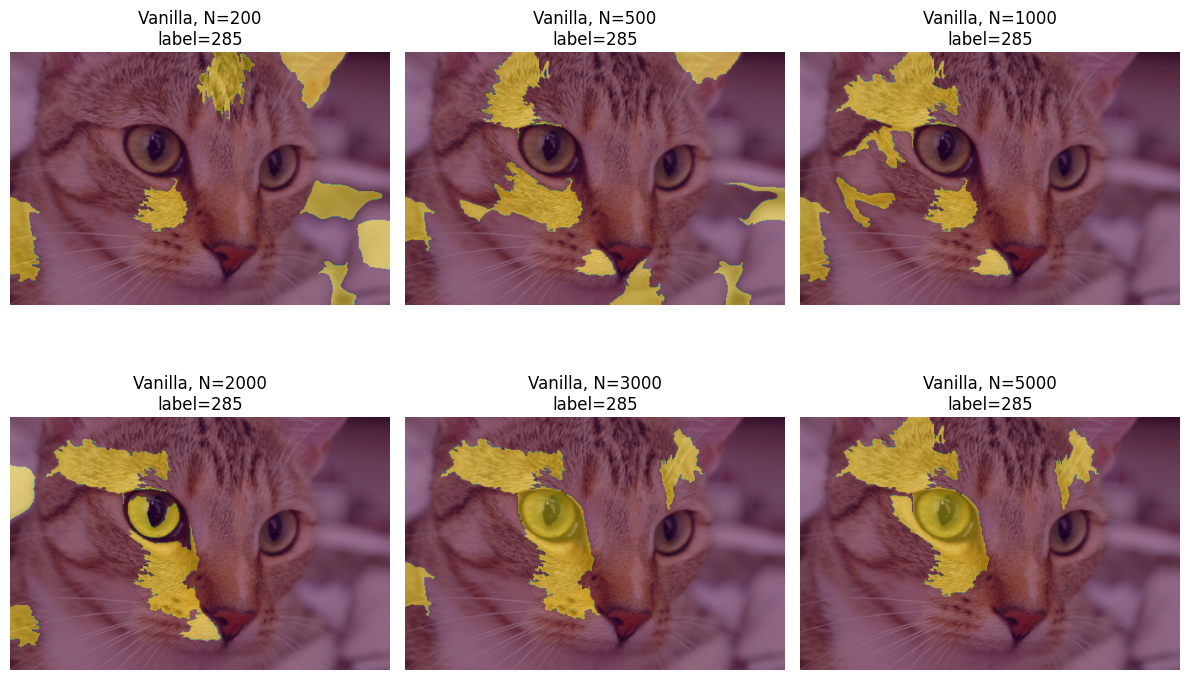

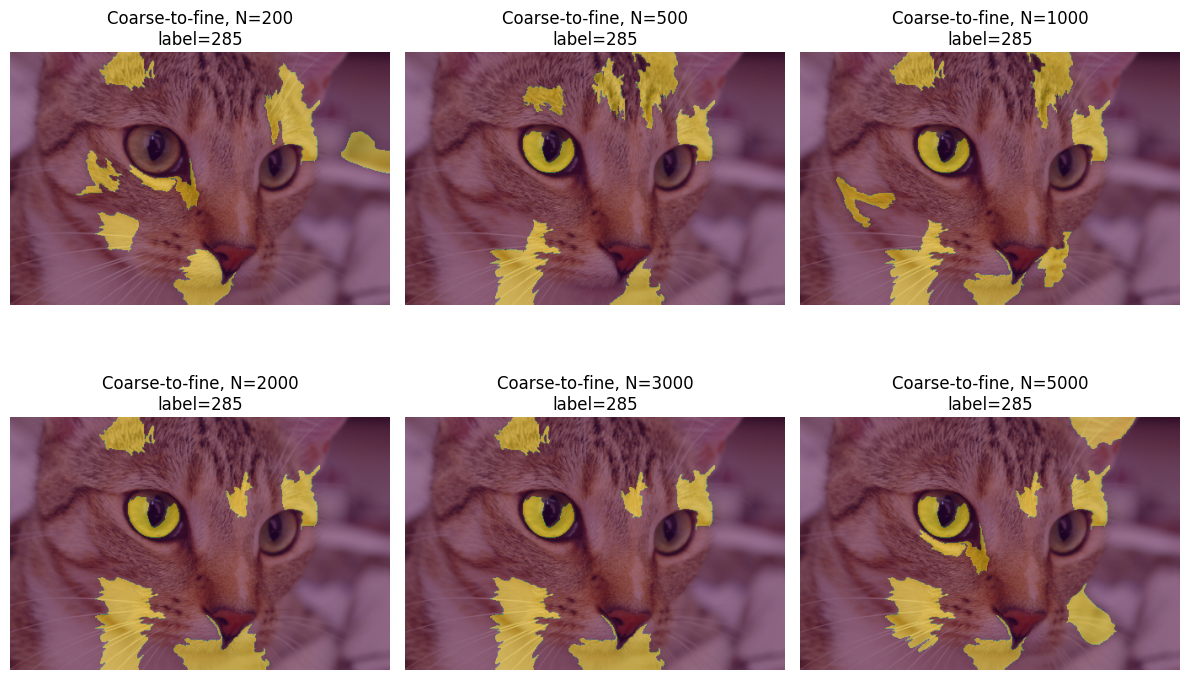

In [130]:
budgets = [200, 500, 1000, 2000, 3000, 5000]

_ = plot_budget_sweep_generic(
    run_lime_image_once_fixed_label,
    img, classifier_fn, segmentation_fn,
    budgets, ref_label,
    seed=0,
    title_prefix="Vanilla"
)

# coarse-to-fine
_ = plot_budget_sweep_generic(
    run_lime_image_once_coarse_to_fine_fixed_label,
    img, classifier_fn, segmentation_fn,
    budgets, ref_label,
    seed=0,
    title_prefix="Coarse-to-fine",
    run_once_kwargs={"coarse_frac":0.2, "candidate_k":20, "batch_size":32, "epsilon":0.2, "adaptive_coarse":True}
)

#### Conclusion
From above visualized plots, our coarse-to-fine budget allocation improves LIME under limited budget. Vanilla LIME only focuses on the eye region at about N = 2000, while our method highlights the eye region already at N = 500 and captures more facial cues such as whiskers and mouth.